
# Capítulo 6, Sección 6.3 — Ejemplo 6 - Juan José Salazar Bedoya - Cristian Camilo Victoria Parra
## Problemas multifísicos acoplados con PINNs

Este cuaderno replica la idea computacional del **Ejemplo 6**: una PINN monolítica para un problema multifísico acoplado, inspirado en interacción fluido-estructura.

El libro plantea un dominio fluido con Navier-Stokes incomprensible,

$
\frac{\partial \mathbf u}{\partial t}+ (\mathbf u\cdot \nabla)\mathbf u
= -\nabla p+\nu \nabla^2\mathbf u,
\qquad \nabla\cdot \mathbf u=0,
$

un dominio sólido con elastodinámica lineal,

$
\rho_s\frac{\partial^2\mathbf d}{\partial t^2}=\nabla\cdot \sigma(\mathbf d)+\mathbf f_s,
$

y condiciones de interfaz

$
\mathbf u=\frac{\partial \mathbf d}{\partial t},
\qquad
\sigma_f\mathbf n=\sigma_s\mathbf n.
$

Como el texto no da una geometría ni datos numéricos completos, aquí se usa un **caso manufacturado** en dos dominios rectangulares para que el notebook sea ejecutable y verificable. La intención pedagógica es la misma: red con salida múltiple, pérdidas por dominio, pérdidas de frontera, pérdidas de interfaz y autograd para derivadas.



## Geometría

Tomamos el rectángulo unitario, separado por la interfaz horizontal

$
\Gamma=\{(x,y):0\le x\le 1,\ y=0.5\}.
$

El fluido ocupa $\Omega_f=[0,1]\times[0,0.5]$ y el sólido ocupa $\Omega_s=[0,1]\times[0.5,1]$. La red recibe

$
(x,y,t,\mathrm{id}_{\Omega})
$

y devuelve

$
(\widehat u,\widehat v,\widehat p,\widehat d_x,\widehat d_y).
$

En el fluido se usan $(\widehat u,\widehat v,\widehat p)$; en el sólido se usan $(\widehat d_x,\widehat d_y)$.


In [ ]:

import time
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

np.random.seed(7)
torch.manual_seed(7)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('PyTorch', torch.__version__, '| dispositivo:', device)


PyTorch 2.11.0+cpu | dispositivo: cpu


In [ ]:

# Parámetros geométricos y físicos
pi = np.pi
T_FINAL = 1.0
Y_INTERFACE = 0.5

# Fluido
nu = 0.02

# Sólido lineal elástico
rho_s = 1.0
lambda_s = 1.0
mu_s = 0.5

# Solución manufacturada
A = 0.15
B = 0.08
C = 0.25
PAMP = 0.10

# Puntos de entrenamiento
N_f = 45
N_s = 45
N_b_side = 15
N_gamma = 35
N_ic = 35

N_STEPS = 1500 if device.type == 'cuda' else 250
PRINT_EVERY = max(100, N_STEPS // 5)
print('Iteraciones:', N_STEPS)


Iteraciones: 250



## Funciones exactas manufacturadas

Estas funciones se introducen para cerrar el experimento computacional. No son datos explícitos del libro. Sirven para generar fuentes, condiciones iniciales/frontera y una referencia de validación.


In [ ]:

def to_col(a, requires_grad=False):
    if isinstance(a, torch.Tensor):
        t = a.to(device=device, dtype=torch.float32).reshape(-1, 1)
    else:
        t = torch.tensor(a, dtype=torch.float32, device=device).reshape(-1, 1)
    return t.requires_grad_(requires_grad)


def grad(outputs, inputs):
    return torch.autograd.grad(
        outputs, inputs,
        grad_outputs=torch.ones_like(outputs),
        create_graph=True,
        retain_graph=True
    )[0]


def qf(y):
    a = Y_INTERFACE
    return y**2 * (a - y)**4


def qf_y(y):
    a = Y_INTERFACE
    return 2*y*(a-y)**4 - 4*y**2*(a-y)**3


def qs(y):
    a = Y_INTERFACE
    return (y - a)**4 * (1 - y)**2


def exact_fluid_torch(x, y, t):
    E = torch.exp(-t)
    u = A * E * torch.sin(pi*x) * qf_y(y)
    v = -A * E * pi * torch.cos(pi*x) * qf(y) + C * E
    p = PAMP * E * torch.cos(pi*x) * (Y_INTERFACE - y)**2
    return u, v, p


def exact_solid_torch(x, y, t):
    E = torch.exp(-t)
    d1 = B * E * torch.sin(pi*x) * qs(y)
    d2 = -C * E + B * E * torch.cos(pi*x) * qs(y)
    return d1, d2


def exact_solid_velocity_torch(x, y, t):
    # Derivada temporal exacta de d1,d2.
    E = torch.exp(-t)
    d1_t = -B * E * torch.sin(pi*x) * qs(y)
    d2_t = C * E - B * E * torch.cos(pi*x) * qs(y)
    return d1_t, d2_t


In [ ]:

def solid_stress(d1, d2, x, y):
    # sigma = lambda tr(epsilon) I + 2 mu epsilon
    d1_x = grad(d1, x)
    d1_y = grad(d1, y)
    d2_x = grad(d2, x)
    d2_y = grad(d2, y)

    tr = d1_x + d2_y
    sig_xx = lambda_s * tr + 2*mu_s*d1_x
    sig_yy = lambda_s * tr + 2*mu_s*d2_y
    sig_xy = mu_s * (d1_y + d2_x)
    return sig_xx, sig_xy, sig_yy


def exact_fluid_source(x, y, t):
    # F = u_t + (u·grad)u + grad p - nu Delta u
    x0 = x.detach().clone().requires_grad_(True)
    y0 = y.detach().clone().requires_grad_(True)
    t0 = t.detach().clone().requires_grad_(True)

    u, v, p = exact_fluid_torch(x0, y0, t0)

    u_t = grad(u, t0)
    u_x = grad(u, x0); u_y = grad(u, y0)
    v_t = grad(v, t0)
    v_x = grad(v, x0); v_y = grad(v, y0)
    p_x = grad(p, x0); p_y = grad(p, y0)

    u_xx = grad(u_x, x0); u_yy = grad(u_y, y0)
    v_xx = grad(v_x, x0); v_yy = grad(v_y, y0)

    Fu = u_t + u*u_x + v*u_y + p_x - nu*(u_xx + u_yy)
    Fv = v_t + u*v_x + v*v_y + p_y - nu*(v_xx + v_yy)
    return Fu.detach(), Fv.detach()


def exact_solid_source(x, y, t):
    # S = rho d_tt - div sigma(d)
    x0 = x.detach().clone().requires_grad_(True)
    y0 = y.detach().clone().requires_grad_(True)
    t0 = t.detach().clone().requires_grad_(True)

    d1, d2 = exact_solid_torch(x0, y0, t0)
    d1_t = grad(d1, t0); d2_t = grad(d2, t0)
    d1_tt = grad(d1_t, t0); d2_tt = grad(d2_t, t0)

    sig_xx, sig_xy, sig_yy = solid_stress(d1, d2, x0, y0)
    div_sig_x = grad(sig_xx, x0) + grad(sig_xy, y0)
    div_sig_y = grad(sig_xy, x0) + grad(sig_yy, y0)

    S1 = rho_s*d1_tt - div_sig_x
    S2 = rho_s*d2_tt - div_sig_y
    return S1.detach(), S2.detach()



## Muestreo sin malla

Se toman puntos aleatorios en el fluido, en el sólido, en las fronteras exteriores, en la interfaz y en el tiempo inicial.


In [ ]:

def sample_fluid(n):
    x = np.random.rand(n)
    y = Y_INTERFACE * np.random.rand(n)
    t = T_FINAL * np.random.rand(n)
    return x, y, t


def sample_solid(n):
    x = np.random.rand(n)
    y = Y_INTERFACE + (1 - Y_INTERFACE) * np.random.rand(n)
    t = T_FINAL * np.random.rand(n)
    return x, y, t


def sample_interface(n):
    x = np.random.rand(n)
    y = np.full(n, Y_INTERFACE)
    t = T_FINAL * np.random.rand(n)
    return x, y, t


def sample_fluid_boundary(n_side):
    s = np.random.rand(n_side)
    r = np.random.rand(n_side)
    x = np.concatenate([np.zeros(n_side), np.ones(n_side), s])
    y = np.concatenate([Y_INTERFACE*r, Y_INTERFACE*r, np.zeros(n_side)])
    t = T_FINAL * np.random.rand(3*n_side)
    return x, y, t


def sample_solid_boundary(n_side):
    s = np.random.rand(n_side)
    r = np.random.rand(n_side)
    x = np.concatenate([np.zeros(n_side), np.ones(n_side), s])
    y = np.concatenate([
        Y_INTERFACE + (1-Y_INTERFACE)*r,
        Y_INTERFACE + (1-Y_INTERFACE)*r,
        np.ones(n_side)
    ])
    t = T_FINAL * np.random.rand(3*n_side)
    return x, y, t

# Puntos interiores
xf, yf, tf = sample_fluid(N_f)
xs, ys, ts = sample_solid(N_s)

# Fronteras exteriores
xbf, ybf, tbf = sample_fluid_boundary(N_b_side)
xbs, ybs, tbs = sample_solid_boundary(N_b_side)

# Interfaz
xg, yg, tg = sample_interface(N_gamma)

# Condición inicial
xic_f, yic_f, _ = sample_fluid(N_ic)
tic_f = np.zeros(N_ic)
xic_s, yic_s, _ = sample_solid(N_ic)
tic_s = np.zeros(N_ic)

# Tensores
x_f = to_col(xf, True); y_f = to_col(yf, True); t_f = to_col(tf, True)
x_s = to_col(xs, True); y_s = to_col(ys, True); t_s = to_col(ts, True)

x_bf = to_col(xbf); y_bf = to_col(ybf); t_bf = to_col(tbf)
x_bs = to_col(xbs); y_bs = to_col(ybs); t_bs = to_col(tbs)

x_g = to_col(xg, True); y_g = to_col(yg, True); t_g = to_col(tg, True)

x_ic_f = to_col(xic_f); y_ic_f = to_col(yic_f); t_ic_f = to_col(tic_f)
x_ic_s = to_col(xic_s); y_ic_s = to_col(yic_s); t_ic_s = to_col(tic_s, True)

print('Puntos fluido:', x_f.shape[0])
print('Puntos sólido:', x_s.shape[0])
print('Puntos interfaz:', x_g.shape[0])
print('Puntos frontera fluido:', x_bf.shape[0])
print('Puntos frontera sólido:', x_bs.shape[0])


Puntos fluido: 45
Puntos sólido: 45
Puntos interfaz: 35
Puntos frontera fluido: 45
Puntos frontera sólido: 45


In [ ]:

# Precomputamos las fuentes manufacturadas en los puntos interiores.
# Esto evita recalcular autograd de la solución exacta en cada iteración.
print('Precomputando fuentes manufacturadas...')
Fu_f, Fv_f = exact_fluid_source(x_f, y_f, t_f)
S1_s, S2_s = exact_solid_source(x_s, y_s, t_s)
print('Listo.')


Precomputando fuentes manufacturadas...
Listo.


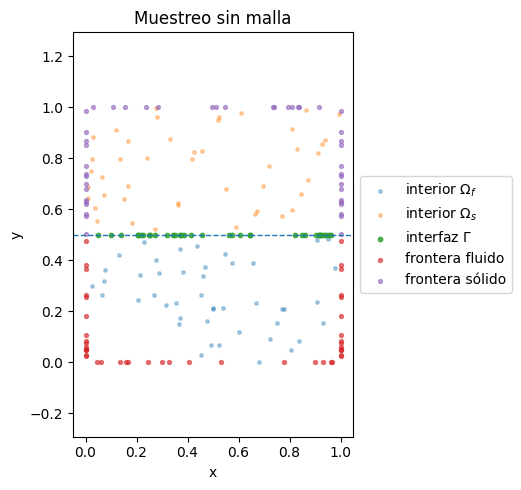

In [ ]:

plt.figure(figsize=(5.2, 5.0))
plt.scatter(xf, yf, s=6, alpha=0.35, label=r'interior $\Omega_f$')
plt.scatter(xs, ys, s=6, alpha=0.35, label=r'interior $\Omega_s$')
plt.scatter(xg, yg, s=10, alpha=0.8, label=r'interfaz $\Gamma$')
plt.scatter(xbf, ybf, s=8, alpha=0.6, label='frontera fluido')
plt.scatter(xbs, ybs, s=8, alpha=0.6, label='frontera sólido')
plt.axhline(Y_INTERFACE, linestyle='--', linewidth=1)
plt.xlabel('x'); plt.ylabel('y')
plt.title('Muestreo sin malla')
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.axis('equal'); plt.tight_layout(); plt.show()



## Red monolítica multi-salida

La MLP recibe $(x,y,t,\mathrm{id}_{\Omega})$ y devuelve simultáneamente variables del fluido y del sólido.


In [ ]:

class MultiPhysicsPINN(nn.Module):
    def __init__(self, width=64, depth=5):
        super().__init__()
        dims = [4] + [width]*depth + [5]
        layers = []
        for i in range(len(dims)-1):
            layers.append(nn.Linear(dims[i], dims[i+1]))
            if i < len(dims)-2:
                layers.append(nn.Tanh())
        self.net = nn.Sequential(*layers)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x, y, t, domain_id):
        z = torch.cat([
            2*x - 1,
            2*y - 1,
            2*t/T_FINAL - 1,
            2*domain_id - 1
        ], dim=1)
        return self.net(z)


def split_outputs(out):
    u = out[:, 0:1]
    v = out[:, 1:2]
    p = out[:, 2:3]
    d1 = out[:, 3:4]
    d2 = out[:, 4:5]
    return u, v, p, d1, d2

net = MultiPhysicsPINN(width=32, depth=3).to(device)
print(net)
print('Parámetros entrenables:', sum(p.numel() for p in net.parameters() if p.requires_grad))


MultiPhysicsPINN(
  (net): Sequential(
    (0): Linear(in_features=4, out_features=32, bias=True)
    (1): Tanh()
    (2): Linear(in_features=32, out_features=32, bias=True)
    (3): Tanh()
    (4): Linear(in_features=32, out_features=32, bias=True)
    (5): Tanh()
    (6): Linear(in_features=32, out_features=5, bias=True)
  )
)
Parámetros entrenables: 2437



## Residuales físicos

Fluido:

$
r_u=\widehat u_t+\widehat u\widehat u_x+\widehat v\widehat u_y+\widehat p_x-\nu\Delta \widehat u-F_u,
$

$
r_v=\widehat v_t+\widehat u\widehat v_x+\widehat v\widehat v_y+\widehat p_y-\nu\Delta \widehat v-F_v,
$

$
r_{\mathrm{div}}=\widehat u_x+\widehat v_y.
$

Sólido:

$
\mathbf r_s=\rho_s\widehat{\mathbf d}_{tt}-\nabla\cdot\sigma(\widehat{\mathbf d})-\mathbf S.
$


In [ ]:

def fluid_residual(model, x, y, t, Fu=None, Fv=None):
    dom = torch.zeros_like(x)
    u, v, p, _, _ = split_outputs(model(x, y, t, dom))

    u_t = grad(u, t)
    u_x = grad(u, x); u_y = grad(u, y)
    v_t = grad(v, t)
    v_x = grad(v, x); v_y = grad(v, y)
    p_x = grad(p, x); p_y = grad(p, y)

    u_xx = grad(u_x, x); u_yy = grad(u_y, y)
    v_xx = grad(v_x, x); v_yy = grad(v_y, y)

    if Fu is None or Fv is None:
        Fu, Fv = exact_fluid_source(x, y, t)
    r_u = u_t + u*u_x + v*u_y + p_x - nu*(u_xx + u_yy) - Fu
    r_v = v_t + u*v_x + v*v_y + p_y - nu*(v_xx + v_yy) - Fv
    r_div = u_x + v_y
    return r_u, r_v, r_div


def solid_residual(model, x, y, t, S1=None, S2=None):
    dom = torch.ones_like(x)
    _, _, _, d1, d2 = split_outputs(model(x, y, t, dom))

    d1_t = grad(d1, t); d2_t = grad(d2, t)
    d1_tt = grad(d1_t, t); d2_tt = grad(d2_t, t)

    sig_xx, sig_xy, sig_yy = solid_stress(d1, d2, x, y)
    div_sig_x = grad(sig_xx, x) + grad(sig_xy, y)
    div_sig_y = grad(sig_xy, x) + grad(sig_yy, y)

    if S1 is None or S2 is None:
        S1, S2 = exact_solid_source(x, y, t)
    r1 = rho_s*d1_tt - div_sig_x - S1
    r2 = rho_s*d2_tt - div_sig_y - S2
    return r1, r2


def interface_terms(model, x, y, t):
    dom_f = torch.zeros_like(x)
    dom_s = torch.ones_like(x)

    u_f, v_f, p_f, _, _ = split_outputs(model(x, y, t, dom_f))
    _, _, _, d1_s, d2_s = split_outputs(model(x, y, t, dom_s))

    d1_t = grad(d1_s, t)
    d2_t = grad(d2_s, t)
    kin_1 = u_f - d1_t
    kin_2 = v_f - d2_t

    u_y = grad(u_f, y)
    v_x = grad(v_f, x)
    v_y = grad(v_f, y)
    tf_x = nu*(u_y + v_x)
    tf_y = -p_f + 2*nu*v_y

    _, sig_xy, sig_yy = solid_stress(d1_s, d2_s, x, y)
    ts_x = sig_xy
    ts_y = sig_yy

    dyn_1 = tf_x - ts_x
    dyn_2 = tf_y - ts_y
    return kin_1, kin_2, dyn_1, dyn_2



## Pérdida total

La pérdida sigue la estructura

$
L=\lambda_fL_{NS}+\lambda_sL_{Elastic}+\lambda_{b,f}L_{b,f}+\lambda_{b,s}L_{b,s}+\lambda_\Gamma L_\Gamma.
$

También añadimos condición inicial porque el problema depende del tiempo.


In [ ]:

lambda_NS = 1.0
lambda_elastic = 1.0
lambda_bf = 20.0
lambda_bs = 20.0
lambda_ic = 20.0
lambda_kin = 60.0
lambda_dyn = 5.0


def mse(z):
    return torch.mean(z**2)


def fluid_boundary_loss(model):
    dom = torch.zeros_like(x_bf)
    u, v, _, _, _ = split_outputs(model(x_bf, y_bf, t_bf, dom))
    u_ex, v_ex, _ = exact_fluid_torch(x_bf, y_bf, t_bf)
    return mse(u - u_ex.detach()) + mse(v - v_ex.detach())


def solid_boundary_loss(model):
    dom = torch.ones_like(x_bs)
    _, _, _, d1, d2 = split_outputs(model(x_bs, y_bs, t_bs, dom))
    d1_ex, d2_ex = exact_solid_torch(x_bs, y_bs, t_bs)
    return mse(d1 - d1_ex.detach()) + mse(d2 - d2_ex.detach())


def initial_loss(model):
    dom_f = torch.zeros_like(x_ic_f)
    u, v, _, _, _ = split_outputs(model(x_ic_f, y_ic_f, t_ic_f, dom_f))
    u_ex, v_ex, _ = exact_fluid_torch(x_ic_f, y_ic_f, t_ic_f)
    Lf_ic = mse(u - u_ex.detach()) + mse(v - v_ex.detach())

    dom_s = torch.ones_like(x_ic_s)
    _, _, _, d1, d2 = split_outputs(model(x_ic_s, y_ic_s, t_ic_s, dom_s))
    d1_ex, d2_ex = exact_solid_torch(x_ic_s, y_ic_s, t_ic_s)
    d1_t = grad(d1, t_ic_s)
    d2_t = grad(d2, t_ic_s)

    d1e_t, d2e_t = exact_solid_velocity_torch(x_ic_s, y_ic_s, t_ic_s)
    Ls_ic = mse(d1 - d1_ex.detach()) + mse(d2 - d2_ex.detach()) + mse(d1_t - d1e_t.detach()) + mse(d2_t - d2e_t.detach())
    return Lf_ic + Ls_ic


def loss_terms(model):
    r_u, r_v, r_div = fluid_residual(model, x_f, y_f, t_f, Fu_f, Fv_f)
    L_NS = mse(r_u) + mse(r_v) + mse(r_div)

    r1, r2 = solid_residual(model, x_s, y_s, t_s, S1_s, S2_s)
    L_el = mse(r1) + mse(r2)

    L_bf = fluid_boundary_loss(model)
    L_bs = solid_boundary_loss(model)
    L_ic = initial_loss(model)

    kin_1, kin_2, dyn_1, dyn_2 = interface_terms(model, x_g, y_g, t_g)
    L_kin = mse(kin_1) + mse(kin_2)
    L_dyn = mse(dyn_1) + mse(dyn_2)

    total = (lambda_NS*L_NS + lambda_elastic*L_el + lambda_bf*L_bf + lambda_bs*L_bs
             + lambda_ic*L_ic + lambda_kin*L_kin + lambda_dyn*L_dyn)

    return {
        'total': total, 'NS': L_NS, 'elastic': L_el,
        'bf': L_bf, 'bs': L_bs, 'ic': L_ic,
        'kin': L_kin, 'dyn': L_dyn
    }



## Entrenamiento

Para una corrida rápida se usa Adam. En GPU puede aumentar `N_STEPS` y los puntos de muestreo.


In [ ]:

optimizer = torch.optim.Adam(net.parameters(), lr=1e-3)
hist = {k: [] for k in ['total', 'NS', 'elastic', 'bf', 'bs', 'ic', 'kin', 'dyn']}

start = time.time()
for it in range(N_STEPS + 1):
    optimizer.zero_grad(set_to_none=True)
    terms = loss_terms(net)
    loss = terms['total']
    loss.backward()
    torch.nn.utils.clip_grad_norm_(net.parameters(), max_norm=10.0)
    optimizer.step()

    for k in hist:
        hist[k].append(float(terms[k].detach().cpu()))

    if it % PRINT_EVERY == 0:
        msg = (f"it={it:5d} | total={hist['total'][-1]:.3e} | NS={hist['NS'][-1]:.3e} | "
               f"El={hist['elastic'][-1]:.3e} | kin={hist['kin'][-1]:.3e} | dyn={hist['dyn'][-1]:.3e}")
        print(msg)

print(f"Tiempo total: {time.time()-start:.1f} s")


it=    0 | total=1.627e+02 | NS=6.313e+00 | El=2.081e+00 | kin=6.323e-01 | dyn=5.165e+00
it=  100 | total=3.990e-02 | NS=8.892e-03 | El=7.970e-03 | kin=8.684e-05 | dyn=3.499e-04
it=  200 | total=1.857e-02 | NS=4.489e-03 | El=4.419e-03 | kin=3.699e-05 | dyn=1.257e-04
Tiempo total: 9.7 s


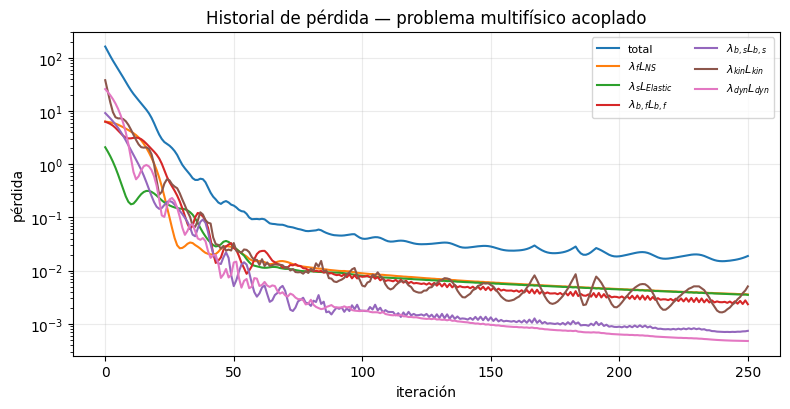

In [ ]:

plt.figure(figsize=(8, 4.2))
plt.semilogy(hist['total'], label='total')
plt.semilogy(np.array(hist['NS'])*lambda_NS, label=r'$\lambda_f L_{NS}$')
plt.semilogy(np.array(hist['elastic'])*lambda_elastic, label=r'$\lambda_s L_{Elastic}$')
plt.semilogy(np.array(hist['bf'])*lambda_bf, label=r'$\lambda_{b,f}L_{b,f}$')
plt.semilogy(np.array(hist['bs'])*lambda_bs, label=r'$\lambda_{b,s}L_{b,s}$')
plt.semilogy(np.array(hist['kin'])*lambda_kin, label=r'$\lambda_{kin}L_{kin}$')
plt.semilogy(np.array(hist['dyn'])*lambda_dyn, label=r'$\lambda_{dyn}L_{dyn}$')
plt.xlabel('iteración')
plt.ylabel('pérdida')
plt.title('Historial de pérdida — problema multifísico acoplado')
plt.grid(True, alpha=0.25)
plt.legend(ncol=2, fontsize=8)
plt.tight_layout(); plt.show()



## Validación visual

Se dibuja un campo combinado: abajo la magnitud de velocidad del fluido y arriba la magnitud de desplazamiento del sólido. No es una única variable física; es solo una visualización compacta.


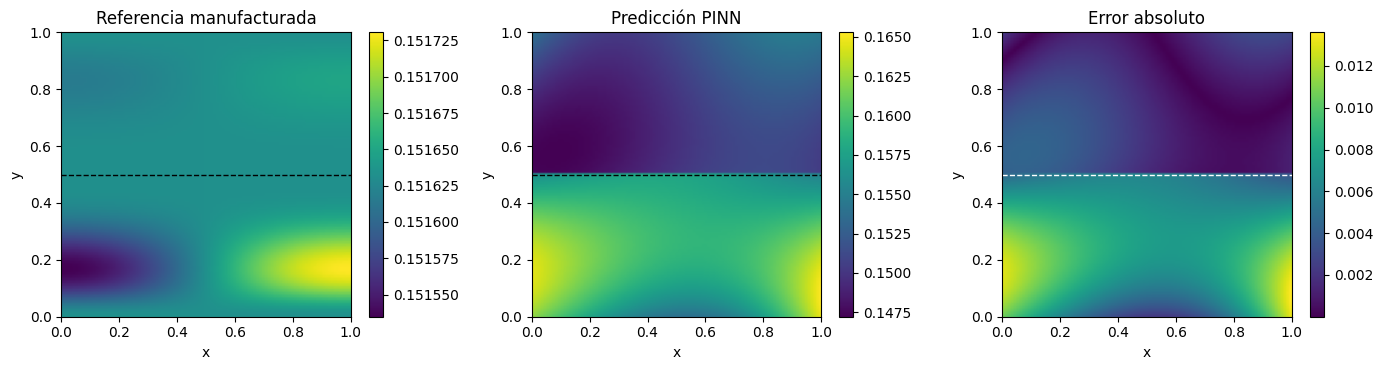

Error relativo L2 del campo combinado en t=0.5: 3.911e-02
Error máximo absoluto: 1.360e-02


In [ ]:

def exact_combined_np(X, Y, T):
    E = np.exp(-T)
    a = Y_INTERFACE
    q = Y**2 * (a - Y)**4
    qy = 2*Y*(a-Y)**4 - 4*Y**2*(a-Y)**3
    u = A * E * np.sin(pi*X) * qy
    v = -A * E * pi * np.cos(pi*X) * q + C*E
    fluid_mag = np.sqrt(u**2 + v**2)

    qs_np = (Y-a)**4 * (1-Y)**2
    d1 = B * E * np.sin(pi*X) * qs_np
    d2 = -C*E + B * E * np.cos(pi*X) * qs_np
    solid_mag = np.sqrt(d1**2 + d2**2)
    return np.where(Y <= a, fluid_mag, solid_mag)


def predict_combined(model, X, Y, Tval):
    xx = to_col(X.ravel())
    yy = to_col(Y.ravel())
    tt = to_col(np.full(X.size, Tval))
    dom = to_col((Y.ravel() > Y_INTERFACE).astype(np.float32))
    with torch.no_grad():
        out = model(xx, yy, tt, dom)
        u, v, p, d1, d2 = split_outputs(out)
        mag_f = torch.sqrt(u**2 + v**2)
        mag_s = torch.sqrt(d1**2 + d2**2)
        mag = torch.where(dom < 0.5, mag_f, mag_s)
    return mag.cpu().numpy().reshape(X.shape)

n_plot = 101
xv = np.linspace(0, 1, n_plot)
yv = np.linspace(0, 1, n_plot)
X, Y = np.meshgrid(xv, yv, indexing='xy')
T_PLOT = 0.5

U_exact = exact_combined_np(X, Y, T_PLOT)
U_pred = predict_combined(net, X, Y, T_PLOT)
ERR = np.abs(U_pred - U_exact)

fig, axs = plt.subplots(1, 3, figsize=(14, 3.8))

im0 = axs[0].imshow(U_exact, origin='lower', extent=[0,1,0,1], aspect='auto')
axs[0].axhline(Y_INTERFACE, color='k', linestyle='--', linewidth=1)
axs[0].set_title('Referencia manufacturada')
axs[0].set_xlabel('x'); axs[0].set_ylabel('y')
fig.colorbar(im0, ax=axs[0])

im1 = axs[1].imshow(U_pred, origin='lower', extent=[0,1,0,1], aspect='auto')
axs[1].axhline(Y_INTERFACE, color='k', linestyle='--', linewidth=1)
axs[1].set_title('Predicción PINN')
axs[1].set_xlabel('x'); axs[1].set_ylabel('y')
fig.colorbar(im1, ax=axs[1])

im2 = axs[2].imshow(ERR, origin='lower', extent=[0,1,0,1], aspect='auto')
axs[2].axhline(Y_INTERFACE, color='w', linestyle='--', linewidth=1)
axs[2].set_title('Error absoluto')
axs[2].set_xlabel('x'); axs[2].set_ylabel('y')
fig.colorbar(im2, ax=axs[2])

plt.tight_layout(); plt.show()

rel_l2 = np.sqrt(np.mean((U_pred-U_exact)**2)) / np.sqrt(np.mean(U_exact**2))
print(f'Error relativo L2 del campo combinado en t={T_PLOT}: {rel_l2:.3e}')
print(f'Error máximo absoluto: {ERR.max():.3e}')



## Chequeo de acoplamiento en la interfaz

Revisamos las dos condiciones centrales:

$
\mathbf u-\mathbf d_t\approx 0,
\qquad
\sigma_f\mathbf n-\sigma_s\mathbf n\approx 0.
$


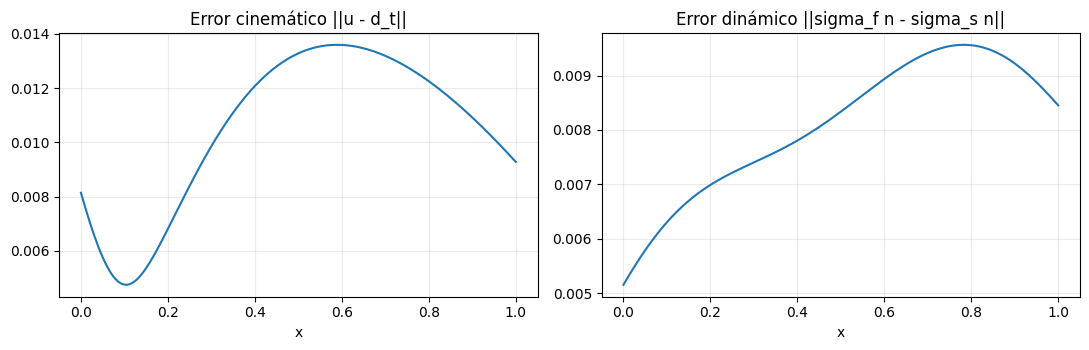

Promedio error cinemático: 0.010506303
Promedio error dinámico: 0.008090502


In [ ]:

xline = np.linspace(0, 1, 200)
yline = np.full_like(xline, Y_INTERFACE)
tline = np.full_like(xline, 0.5)

xL = to_col(xline, True); yL = to_col(yline, True); tL = to_col(tline, True)
kin1, kin2, dyn1, dyn2 = interface_terms(net, xL, yL, tL)

kin_norm = torch.sqrt(kin1**2 + kin2**2).detach().cpu().numpy().ravel()
dyn_norm = torch.sqrt(dyn1**2 + dyn2**2).detach().cpu().numpy().ravel()

fig, axs = plt.subplots(1, 2, figsize=(11, 3.6))
axs[0].plot(xline, kin_norm)
axs[0].set_title('Error cinemático ||u - d_t||')
axs[0].set_xlabel('x'); axs[0].grid(True, alpha=0.25)

axs[1].plot(xline, dyn_norm)
axs[1].set_title('Error dinámico ||sigma_f n - sigma_s n||')
axs[1].set_xlabel('x'); axs[1].grid(True, alpha=0.25)

plt.tight_layout(); plt.show()

print('Promedio error cinemático:', kin_norm.mean())
print('Promedio error dinámico:', dyn_norm.mean())



## Lectura del resultado

Este ejemplo es más conceptual que los anteriores: el libro no da un benchmark numérico cerrado, sino el diseño de una PINN para problemas multifísicos. Por eso este notebook debe leerse como un **prototipo fiel a la arquitectura de pérdida**:

1. una sola red monolítica;
2. salida múltiple para campos físicos distintos;
3. residuo de Navier-Stokes en $\Omega_f$;
4. residuo elástico en $\Omega_s$;
5. pérdidas de frontera en cada dominio;
6. pérdidas de interfaz para cinemática y dinámica.

Lo más importante no es solo si baja la pérdida total, sino si bajan las pérdidas de interfaz. En problemas multifísicos el entrenamiento puede verse bonito mientras el acoplamiento sigue siendo malo. Ese desbalance entre términos de pérdida es precisamente la dificultad central.
